# Ringing Fix Step-by-Step

This notebook reproduces the ringing in the time-resolved IQ traces and tests the proposed fixes one by one without modifying the library code yet.

The goals are:

- identify whether the visible ringing is coming mainly from startup transient or demodulation leakage,
- compare fixes in isolation,
- estimate a realistic readout start time,
- translate the notebook outcome into a concrete library implementation plan.

The fixes tested are:

- stronger low-pass filtering,
- smooth RF carrier ramp-on,
- refined IQ demodulation,
- delayed integration start after resonator settling.

Important interpretation note:

- `I(t)` and `Q(t)` here are already demodulated baseband signals,
- if they still oscillate strongly, that usually means some carrier-scale structure leaked through the demodulation/filtering chain,
- the final IQ clusters can still look good because time integration averages away fast oscillations.


In [20]:
import os
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / 'src'))

from readout_simulator import QuantumDotSystem, RLC_sensor, JAXReadoutSimulator, OverFNoise

plt.rcParams['figure.dpi'] = 140
jax.config.update('jax_enable_x64', True)


In [21]:
def make_system():
    # Two-dot, one-sensor test system chosen to be close to the examples already
    # used elsewhere in the repository. The point here is not device realism in every
    # detail, but to get a stable and reproducible ringing benchmark.
    Cdd = jnp.array([[1.0, 0.10],
                     [0.10, 1.0]])
    Cds = jnp.array([[0.6],
                     [0.3]])
    dot_system = QuantumDotSystem(Cdd, Cds)

    # Default resonator parameters from the current simulation examples.
    params_resonator = {
        'Lc': 800e-9,
        'Cp': 0.5e-12,
        'RL': 40,
        'Rc': 100e6,
        'Z0': 50,
    }

    params_coulomb_peak = {
        'g0': 1 / 50,
        'eps0': 0.5,
        'eps_width': 1.0,
    }

    # Only epsilon noise is used here. Capacitance noise is left off so the notebook
    # isolates the demodulation / filtering behavior more clearly.
    eps_noise = OverFNoise(
        n_fluctuators=3,
        S1=1e-6,
        sigma_couplings=0.1,
        ommax=1e6,
        ommin=1e3,
        equally_dist=True,
    )

    sensor = RLC_sensor(params_resonator, params_coulomb_peak, None, eps_noise)
    simulator = JAXReadoutSimulator(dot_system, [sensor])

    charge_states = jnp.array([
        [1, 0],
        [0, 1],
    ])

    # 1 us window with 0.5 ns sample spacing. This is long enough to see both the
    # early ring-up and the slow integrated convergence.
    t_end = 1e-6
    dt = 0.5e-9
    times = jnp.arange(0, t_end, dt)

    key = jax.random.PRNGKey(42)
    key, subkey = jax.random.split(key)
    simulator.precompute_noise(subkey, times, n_realizations=200, noise_model=eps_noise)

    params = {
        'eps0': 0.0,
        'snr': 1.0,
        't_end': t_end,
    }
    results = simulator.run_simulation(charge_states, times, params, key)

    return dot_system, sensor, simulator, charge_states, times, results


dot_system, sensor, simulator, charge_states, times, results = make_system()
times_np = np.asarray(times)
sensor_results = results['sensor_results'][0]

print(f'f0 = {sensor.f0 / 1e6:.2f} MHz')
print(f'T0 = {sensor.T0 * 1e9:.2f} ns')
print(f'N time points = {len(times)}')


Dot-sensor coupling strength (Δε/ε_w): [[0.57575758 0.24242424]]
[RLC_sensor] Initialized with:
  Lc = 8.000e-07 H
  Cp = 5.000e-13 F
  Self-capacitance = 0.000e+00 F
  Total capacitance = 5.000e-13 F
  RL = 40 Ω
  Rc = 1.000e+08 Ω
  Z0 = 50 Ω
  R0 = 5.000e+01 Ω
  g0 = 2.000e-02 S
  eps_w = 1.000e+00 eV
  Resonant frequency = 2.516e+08 Hz
  Resonant period = 3.974e-09 s
  Capacitance noise model: None
  Energy noise model: OverFNoise
Precomputing 200 noise trajectory segments...
Noise trajectory segments precomputed successfully.
Running simulation for 2 charge states with 200 realizations...
Processing sensor 0...
Sensor 0: Average separation = 0.000187
Simulation completed successfully.
f0 = 251.65 MHz
T0 = 3.97 ns
N time points = 2000


## Baseline simulation

Start by looking at the current library output without any local modifications.

What to look for:

- whether the oscillation is stronger in `I` or `Q`,
- whether the oscillation is mainly early-time ring-up or persists across the trace,
- whether integration suppresses the issue even when the raw time trace looks bad.


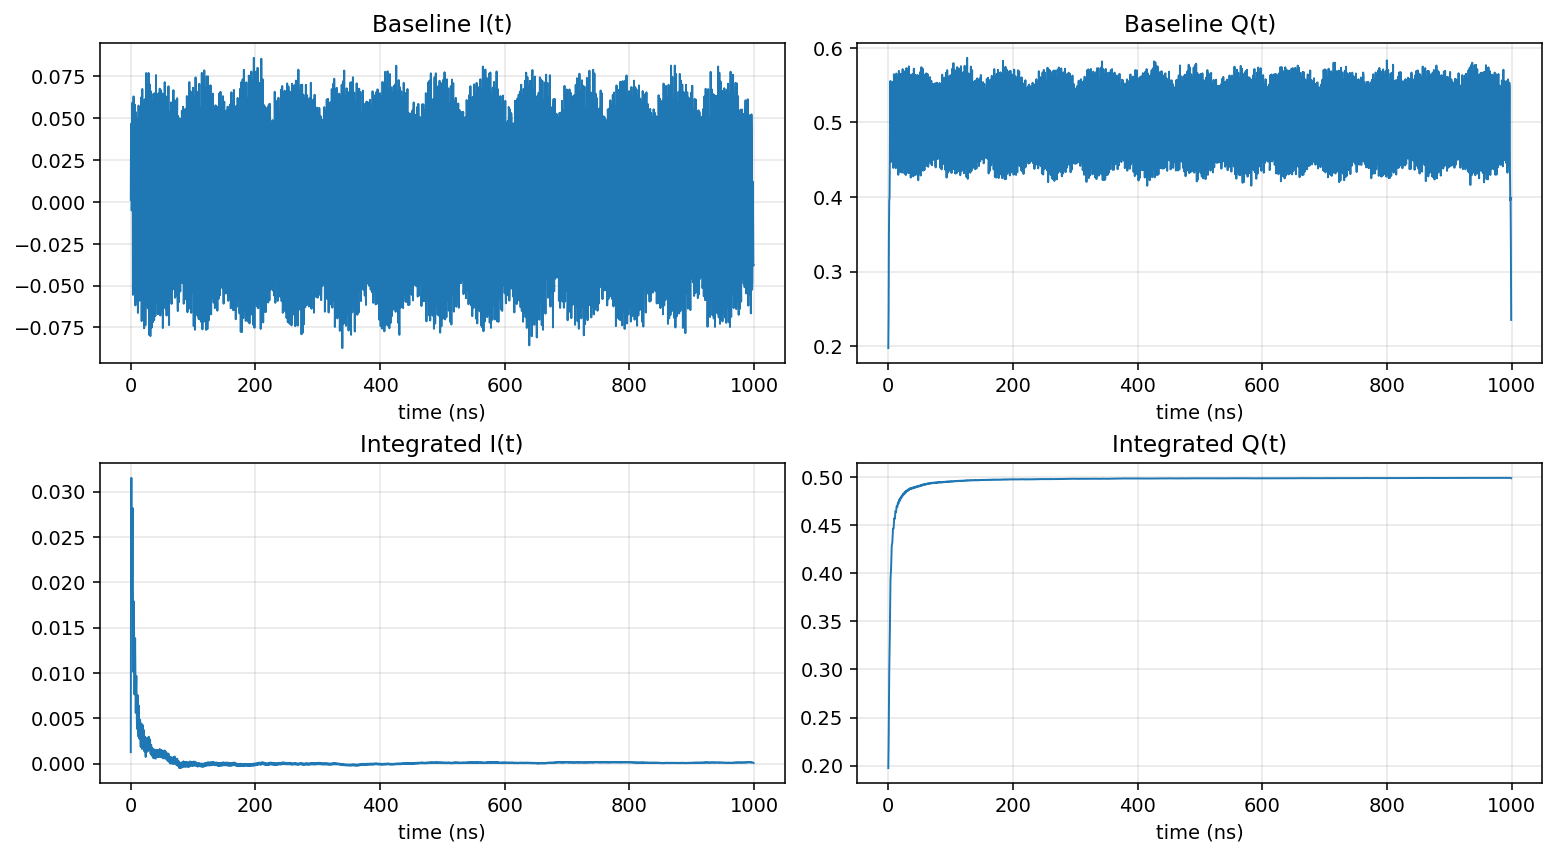

In [22]:
def cumulative_average(x, start_idx=0):
    # Used both for the current integrated-IQ style plots and for delayed-readout tests.
    x = np.asarray(x)
    if start_idx == 0:
        return np.cumsum(x, axis=-1) / np.arange(1, x.shape[-1] + 1)

    y = x[..., start_idx:]
    out = np.full_like(x, np.nan, dtype=float)
    out[..., start_idx:] = np.cumsum(y, axis=-1) / np.arange(1, y.shape[-1] + 1)
    return out


def plot_baseline_ringing(sensor_results, state_idx=0, realization_idx=0):
    I = np.asarray(sensor_results['I'][state_idx, realization_idx])
    Q = np.asarray(sensor_results['Q'][state_idx, realization_idx])
    I_int = cumulative_average(I)
    Q_int = cumulative_average(Q)

    fig, axes = plt.subplots(2, 2, figsize=(11, 6), constrained_layout=True)

    axes[0, 0].plot(times_np * 1e9, I, lw=1)
    axes[0, 0].set_title('Baseline I(t)')
    axes[0, 0].set_xlabel('time (ns)')

    axes[0, 1].plot(times_np * 1e9, Q, lw=1)
    axes[0, 1].set_title('Baseline Q(t)')
    axes[0, 1].set_xlabel('time (ns)')

    axes[1, 0].plot(times_np * 1e9, I_int, lw=1)
    axes[1, 0].set_title('Integrated I(t)')
    axes[1, 0].set_xlabel('time (ns)')

    axes[1, 1].plot(times_np * 1e9, Q_int, lw=1)
    axes[1, 1].set_title('Integrated Q(t)')
    axes[1, 1].set_xlabel('time (ns)')

    for ax in axes.flat:
        ax.grid(alpha=0.3)

    return fig, axes


plot_baseline_ringing(sensor_results);


### Baseline interpretation

Typical baseline behavior in this model:

- `Q(t)` carries most of the visible ringing,
- `I(t)` is often much smaller and averages away quickly,
- `integrated Q(t)` still converges, which explains why final IQ clusters can look well-separated even when the raw trajectory rings.

This already suggests that the core issue is in the readout signal-processing chain, not in the state separation itself.


## Local test implementation of the signal path

The functions below reproduce the JAX signal path and let us switch individual fixes on and off without editing the package source.

Notebook tuning strategy:

- keep the baseline logic identical to the library where possible,
- expose the ramp and filter strength as explicit parameters,
- use milder defaults than the first aggressive test so the recommended settings stay closer to a realistic readout window.


In [23]:
def conductance_from_eps(sensor, eps_values):
    # Same static conductance model used in the JAX sensor backend.
    eps_values = jnp.asarray(eps_values)
    return 2 * jnp.cosh(2 * eps_values / sensor.eps_w) ** (-2) / sensor.R0


def low_pass_filter_moving_average(signal):
    # Current library-like weak low-pass. Useful as the baseline reference.
    signal = jnp.asarray(signal)
    window_size = min(10, max(1, len(signal) // 10))
    kernel = jnp.ones(window_size) / window_size
    return jnp.convolve(signal, kernel, mode='same')


def low_pass_filter_iir(signal, omega0, dt, cutoff_factor=0.15):
    # One-pole IIR low-pass. A larger cutoff_factor means a faster filter with less
    # smoothing. The earlier 0.05 test was effective but too aggressive; 0.15 is a
    # better starting point for implementation.
    tau = 1.0 / (cutoff_factor * omega0)
    alpha = dt / (tau + dt)

    def step(y_prev, x):
        y = y_prev + alpha * (x - y_prev)
        return y, y

    _, y = jax.lax.scan(step, signal[0], signal)
    return y


def compute_signal_variant(sensor, times, conductances, use_ramp=False, use_refined_demod=False, use_strong_lpf=False, ramp_cycles=8, cutoff_factor=0.15):
    times = jnp.asarray(times)
    dt = times[1] - times[0]

    if use_ramp:
        # A modest ramp over ~8 carrier cycles softens the startup without stretching
        # the readout window too much.
        ramp_time = ramp_cycles * (2 * jnp.pi / sensor.omega0)
        ramp = 1.0 - jnp.exp(-times / ramp_time)
    else:
        ramp = jnp.ones_like(times)

    # The carrier is the resonator probe tone. Any residual oscillation after
    # demodulation/filtering is the issue we want to suppress.
    V_s_t = ramp * jnp.sin(sensor.omega0 * times)
    V_refl_t = V_s_t * (1 - conductances / (conductances + sensor.Z0))

    if use_refined_demod:
        # Standard baseband convention: 2*cos and -2*sin.
        I_mixed = 2.0 * V_refl_t * jnp.cos(sensor.omega0 * times)
        Q_mixed = -2.0 * V_refl_t * jnp.sin(sensor.omega0 * times)
    else:
        I_mixed = V_refl_t * jnp.cos(sensor.omega0 * times)
        Q_mixed = V_refl_t * jnp.sin(sensor.omega0 * times)

    if use_strong_lpf:
        I = low_pass_filter_iir(I_mixed, sensor.omega0, dt, cutoff_factor=cutoff_factor)
        Q = low_pass_filter_iir(Q_mixed, sensor.omega0, dt, cutoff_factor=cutoff_factor)
    else:
        I = low_pass_filter_moving_average(I_mixed)
        Q = low_pass_filter_moving_average(Q_mixed)

    return np.asarray(I), np.asarray(Q), np.asarray(V_refl_t)


def build_variant_from_result(sensor, dot_system, charge_state, times, noise_trajectory, *, use_ramp=False, use_refined_demod=False, use_strong_lpf=False, ramp_cycles=8, cutoff_factor=0.15):
    sensor_voltages = jnp.zeros(dot_system.Cds.shape[1])
    eps_offset = dot_system.get_energy_offset(charge_state, sensor_voltages, 0.0)[0]
    eps_values = jnp.asarray(noise_trajectory) + eps_offset
    conductances = conductance_from_eps(sensor, eps_values)
    return compute_signal_variant(
        sensor,
        times,
        conductances,
        use_ramp=use_ramp,
        use_refined_demod=use_refined_demod,
        use_strong_lpf=use_strong_lpf,
        ramp_cycles=ramp_cycles,
        cutoff_factor=cutoff_factor,
    )


### Variant definitions

The variants below are meant to answer a specific question each:

- `baseline`: what the current library-style logic does,
- `strong_lpf`: how much of the ringing disappears if filtering is the only change,
- `ramp_only`: how much is startup transient versus persistent demodulation leakage,
- `refined_demod`: whether scaling/sign cleanup alone is enough,
- `all_fixes`: the combined effect using a milder, more realistic tuning.


In [24]:
state_idx = 0
realization_idx = 0

charge_state = charge_states[state_idx]
noise_trajectory = np.asarray(sensor_results['noise_trajectory'][state_idx, realization_idx])

variants = {
    'baseline': build_variant_from_result(sensor, dot_system, charge_state, times, noise_trajectory),
    'strong_lpf': build_variant_from_result(sensor, dot_system, charge_state, times, noise_trajectory, use_strong_lpf=True, cutoff_factor=0.15),
    'ramp_only': build_variant_from_result(sensor, dot_system, charge_state, times, noise_trajectory, use_ramp=True, ramp_cycles=8),
    'refined_demod': build_variant_from_result(sensor, dot_system, charge_state, times, noise_trajectory, use_refined_demod=True),
    'all_fixes': build_variant_from_result(sensor, dot_system, charge_state, times, noise_trajectory, use_ramp=True, use_refined_demod=True, use_strong_lpf=True, ramp_cycles=8, cutoff_factor=0.15),
}

list(variants.keys())


['baseline', 'strong_lpf', 'ramp_only', 'refined_demod', 'all_fixes']

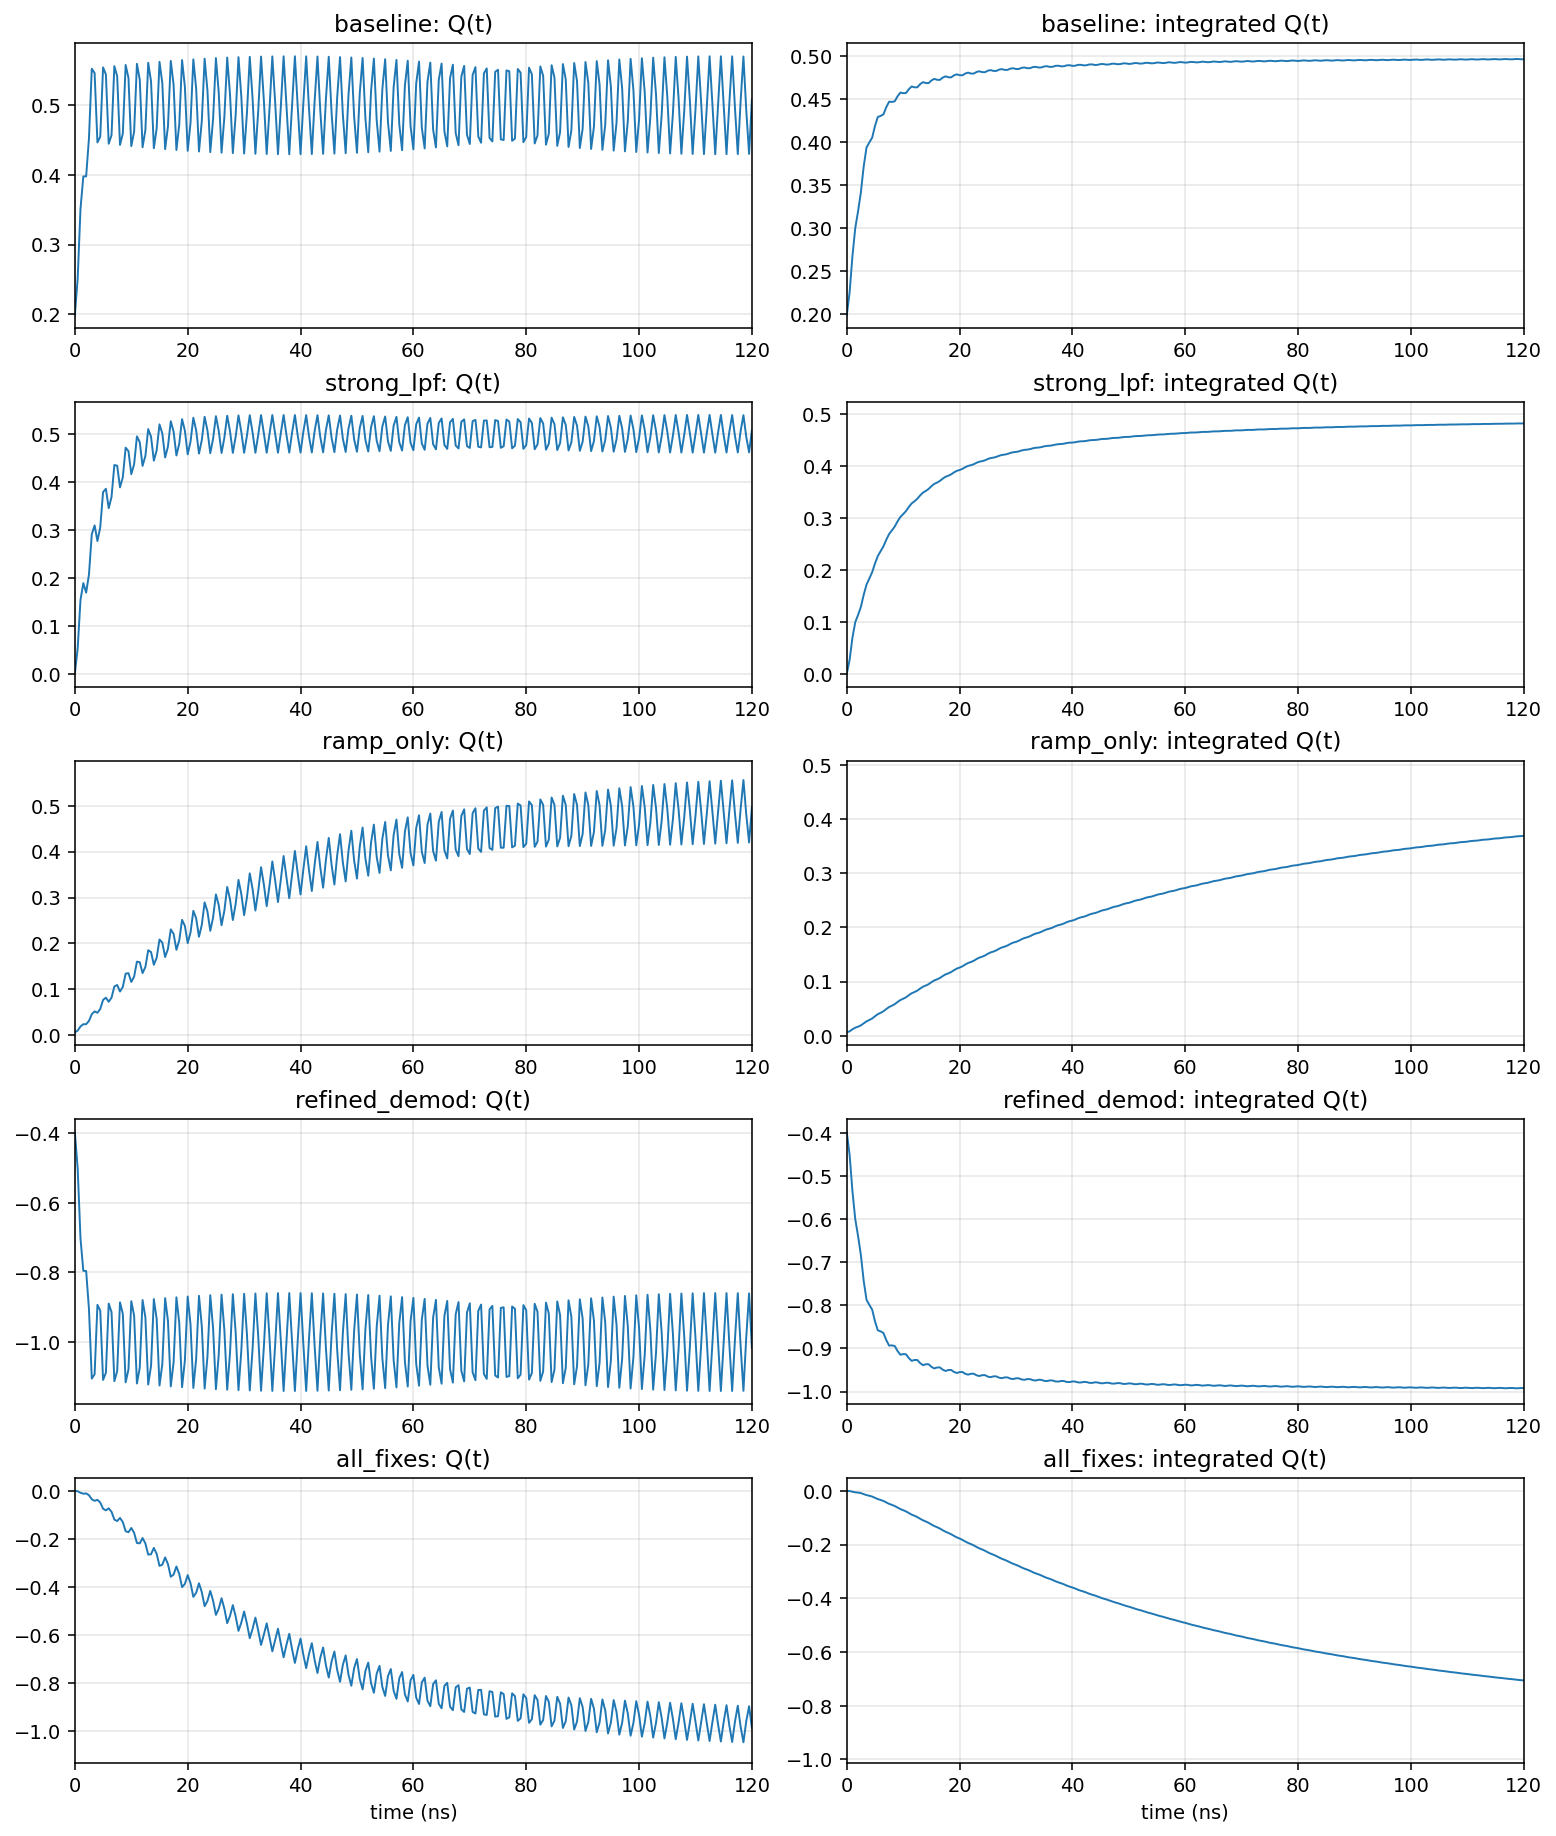

In [25]:
def plot_variant_comparison(variants, times_ns, component='Q', xlim_ns=(0, 150)):
    idx = 0 if component == 'I' else 1
    fig, axes = plt.subplots(len(variants), 2, figsize=(11, 2.6 * len(variants)), constrained_layout=True)

    if len(variants) == 1:
        axes = np.asarray([axes])

    for row, (name, (I, Q, _)) in enumerate(variants.items()):
        signal = I if component == 'I' else Q
        signal_int = cumulative_average(signal)

        axes[row, 0].plot(times_ns, signal, lw=1)
        axes[row, 0].set_title(f'{name}: {component}(t)')
        axes[row, 0].set_xlim(*xlim_ns)
        axes[row, 0].grid(alpha=0.3)

        axes[row, 1].plot(times_ns, signal_int, lw=1)
        axes[row, 1].set_title(f'{name}: integrated {component}(t)')
        axes[row, 1].set_xlim(*xlim_ns)
        axes[row, 1].grid(alpha=0.3)

    for ax in axes[-1, :]:
        ax.set_xlabel('time (ns)')

    return fig, axes


plot_variant_comparison(variants, times_np * 1e9, component='Q', xlim_ns=(0, 120));


### How to read the comparison figure

- If `strong_lpf` helps a lot, the ringing is mostly a filtering / residual-carrier problem.
- If `ramp_only` helps only at very early time, the startup transient is secondary.
- If `refined_demod` mostly changes sign or scale but not oscillation amplitude, it is helpful but not the main fix.
- If `all_fixes` looks best but also becomes too slow, the filter is too aggressive and should be loosened.

The current recommended implementation target is:

- keep the refined demodulation,
- use a modest ramp (`~5-10` carrier cycles),
- use a stronger low-pass than the moving average, but not so strong that it dominates the settling time.


## Realistic readout start: discard the ring-up region

A simple physics-based readout window starts after a few ring-up time constants.


In [26]:
RL_effective = sensor.RL + sensor.Z0
tau_ring = 2 * sensor.Lc / RL_effective
Q_est = sensor.omega0 * sensor.Lc / RL_effective
t_start = 5 * tau_ring
start_idx = int(np.searchsorted(times_np, t_start))

print(f'Estimated Q = {Q_est:.2f}')
print(f'tau_ring = {tau_ring * 1e9:.2f} ns')
print(f't_start = {t_start * 1e9:.2f} ns')
print(f'start_idx = {start_idx}')


Estimated Q = 14.05
tau_ring = 17.78 ns
t_start = 88.89 ns
start_idx = 178


### Readout-window interpretation

The estimate above is for the resonator settling time itself.

In practice the correct readout start is the larger of:

- the physical resonator ring-up time,
- the extra settling introduced by the digital low-pass filter.

So if the filtered signal is still drifting strongly after `t_start`, that is a sign the filter is too slow for the intended readout bandwidth.


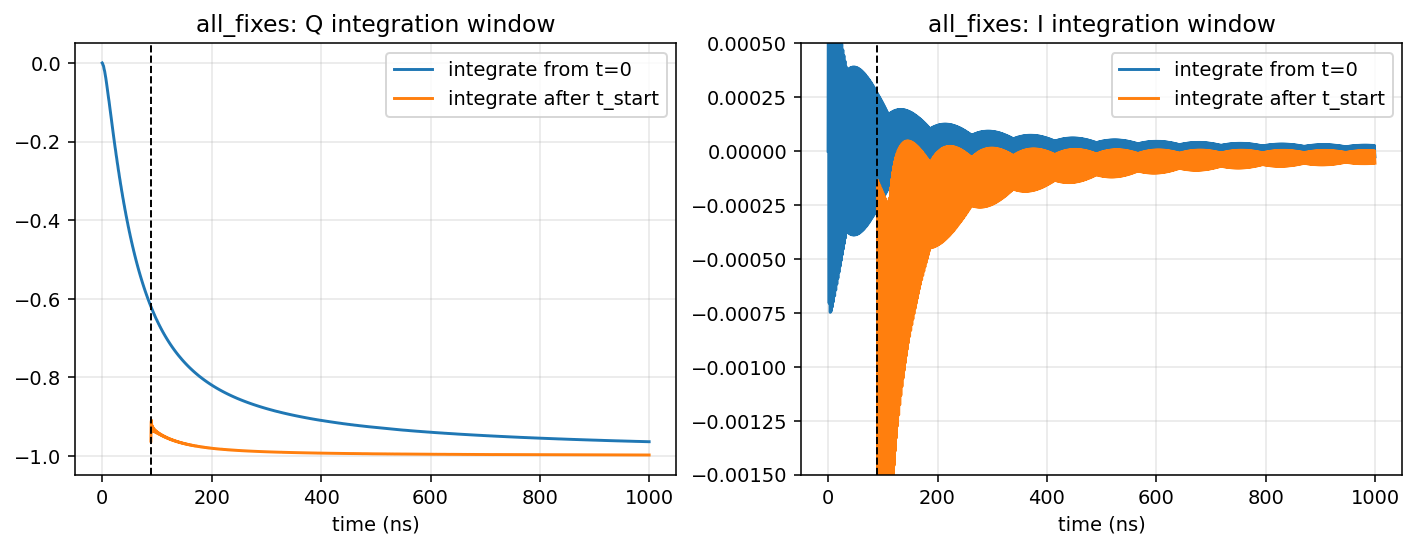

In [29]:
def plot_delayed_integration(variant_name, variant, times_ns, start_idx):
    I, Q, _ = variant
    I_full = cumulative_average(I, start_idx=0)
    Q_full = cumulative_average(Q, start_idx=0)
    I_delayed = cumulative_average(I, start_idx=start_idx)
    Q_delayed = cumulative_average(Q, start_idx=start_idx)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)

    axes[0].plot(times_ns, Q_full, label='integrate from t=0')
    axes[0].plot(times_ns, Q_delayed, label='integrate after t_start')
    axes[0].axvline(times_ns[start_idx], color='k', ls='--', lw=1)
    axes[0].set_title(f'{variant_name}: Q integration window')
    axes[0].set_xlabel('time (ns)')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(times_ns, I_full, label='integrate from t=0')
    axes[1].plot(times_ns, I_delayed, label='integrate after t_start')
    axes[1].axvline(times_ns[start_idx], color='k', ls='--', lw=1)
    axes[1].set_title(f'{variant_name}: I integration window')
    axes[1].set_xlabel('time (ns)')
    axes[1].set_ylim(-0.0015, 0.0005)
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    return fig, axes


plot_delayed_integration('all_fixes', variants['all_fixes'], times_np * 1e9, start_idx);


## Recommended implementation order in the library

1. Replace the moving-average low-pass in `\ReadSpyn\src\readout_simulator\sensor_backend.py`.
   Suggested first value: `cutoff_factor ~ 0.10-0.20`.
2. Add the smooth carrier ramp-on in `get_signal_jax()`.
   Suggested first value: `ramp_cycles ~ 5-10`.
3. Replace the demodulation with the refined `2*cos` / `-2*sin` version.
4. If needed, add delayed integration in `\ReadSpyn\src\readout_simulator\jax_simulator.py`.
   Suggested first value: `t_start ~ max(3-5*tau_ring, ramp_time)`.

Working recommendation after the notebook analysis:

- the low-pass is the dominant fix,
- the ramp helps mostly with the startup edge,
- the refined demodulation should be kept, but it is not sufficient alone,
- avoid an overly aggressive filter, because then the filter becomes the new bottleneck.
